# Ansambli za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

# 1. Ponavljanje nužnih transformacija iz prethodne bilježnice i priprema dataseta

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset.csv')

# brisanje značajke Is_Contactless
del df['Is_Contactless']

# uklanjanje zapisa gdje nedostaju podaci, svi od USER_0007
df = df[df['User_ID'] != 'USER_0007'].copy()

# korekcija neujednačenog označavanja
df['Location'] = df['Location'].replace('Lndn', 'London')
df['Merchant_Category'] = df['Merchant_Category'].replace('Electronis', 'Electronics')

# izbacivanje negativnih i transakcija s iznosom 0
df = df.loc[df['Transaction_Amount'] > 0, :].copy()

# popravljanje Is_Weekend
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df['Is_Weekend'] = df["Timestamp"].dt.dayofweek >= 5

# one-hot encoding
df = pd.get_dummies(df, columns=['Transaction_Type'], prefix='TT')
df = pd.get_dummies(df, columns=['Device_Type'], prefix='DT')
df = pd.get_dummies(df, columns=['Location'], prefix='Loc')
df = pd.get_dummies(df, columns=['Merchant_Category'], prefix='MerchCat')
df = pd.get_dummies(df, columns=['Card_Type'], prefix='CT')
df = pd.get_dummies(df, columns=['Authentication_Method'], prefix='AUM')

# log transform
df['Transaction_Amount'] = np.log1p(df['Transaction_Amount'])

# date transform
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["Year"] = df["Timestamp"].dt.year
df["Day_of_Week"] = df["Timestamp"].dt.dayofweek
df["Quarter"] = df["Timestamp"].dt.quarter

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DOW_sin"] = np.sin(2 * np.pi * df["Day_of_Week"] / 7)
df["DOW_cos"] = np.cos(2 * np.pi * df["Day_of_Week"] / 7)
df["Day_sin"] = np.sin(2 * np.pi * df["Day"] / 31)
df["Day_cos"] = np.cos(2 * np.pi * df["Day"] / 31)

del df['Timestamp']
del df['Day_of_Week']
del df['Day']
del df['Month']
del df['Year']
del df['Quarter']

# ekspertne značajke
df["Amount_vs_Avg7d"] = df["Transaction_Amount"] / (df["Avg_Transaction_Amount_7d"] + 1)
df["Txn_Burst"] = (df["Daily_Transaction_Count"] > 10).astype(int)
df["Weekend_Online"] = df["Is_Weekend"] * df["TT_Online"]

# ============================================================
# PRVO SPLIT, TEK ONDA SCALING
# ============================================================

y = df["Fraud_Label"].copy()
X = df.drop(columns=['Transaction_ID', 'User_ID', 'Fraud_Label']).copy()

# bool -> int
bool_cols = X.select_dtypes(include=['bool']).columns
X.loc[:, bool_cols] = X.loc[:, bool_cols].astype(int)

zz_scale_cols = [
    'Transaction_Amount',
    'Account_Balance',
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d',
    'Failed_Transaction_Count_7d',
    'Card_Age',
    'Transaction_Distance',
    'Amount_vs_Avg7d'
]




C:\Users\Nikolina\AppData\Local\Temp\ipykernel_10372\4240577453.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[:, bool_cols] = X.loc[:, bool_cols].astype(int)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_10372\4240577453.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[:, bool_cols] = X.loc[:, bool_cols].astype(int)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_10372\4240577453.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 0 ... 0 1 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.lo

# 2. Usporedba modela (5-fold CV)
- DT, stacking (NB, DT, LR), bagging (DT), RF, Adaboost, XGBoost

## 2.1. Samo top 2 značajke
- 'Failed_Transaction_Count_7d', 'Risk_Score'

In [2]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier


# scaling
features = ['Failed_Transaction_Count_7d', 'Risk_Score']

scale_cols = [col for col in features if col in zz_scale_cols]
passthrough_cols = [col for col in features if col not in zz_scale_cols]

print("Scaling:", scale_cols)
print("Passthrough:", passthrough_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_cols),
        ("pass", "passthrough", passthrough_cols)
    ]
)




#models
models = {
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=3, random_state=42))
    ]),

    "Stacking": Pipeline([
        ("prep", preprocessor),
        ("model", StackingClassifier(
            estimators=[
                ("dt", DecisionTreeClassifier(max_depth=3, random_state=42)),
                ("nb", GaussianNB()),
                ("lr", LogisticRegression(max_iter=1000))
            ],
            final_estimator=LogisticRegression(),
            cv=5,
        ))
    ]),

    "Bagging": Pipeline([
        ("prep", preprocessor),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=100,
            random_state=42
        ))
    ]),

    "AdaBoost": Pipeline([
        ("prep", preprocessor),
        ("model", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=100,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),

    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=1.0,
            use_label_encoder=False,
            eval_metric="logloss",
            verbosity=0,
            random_state=42
        ))

    ])
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    f1_class0 = []
    f1_class1 = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        acc_scores.append(accuracy_score(y_val, y_pred))

        f1 = f1_score(y_val, y_pred, average=None)
        f1_class0.append(f1[0])
        f1_class1.append(f1[1])

    results.append({
        "Model": name,
        "Accuracy": np.mean(acc_scores),
        "F1_class_0": np.mean(f1_class0),
        "F1_class_1": np.mean(f1_class1)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(results_df)

Scaling: ['Failed_Transaction_Count_7d']
Passthrough: ['Risk_Score']
           Model  Accuracy  F1_class_0  F1_class_1
0  Decision Tree   0.99986    0.999897    0.999782
1       Stacking   0.99986    0.999897    0.999782
2        Bagging   0.99986    0.999897    0.999782
4  Random Forest   0.99978    0.999838    0.999658
3       AdaBoost   0.99974    0.999808    0.999596
5        XGBoost   0.99942    0.999572    0.999098


*U ovom slučaju odabrane dvije značajke, za koje je ranije uočeno da su prema različitim metrikama značajno ispred svih ostalih, su sasvim dovoljne da već jednostavni klasifikator kao što je DT postigne gotovo 100% acc i F1 za obje klase. Korištenje složenijih modela, kao ni više značajki, neće doprinijeti poboljšanju jer ovih 0.0001 su najvjerojatnije pogrešno označeni primjerci*

# 3. Objašnjavanje modela
A. Globalno:
   - prikaz DT-a
   - permutation importance, SHAP barchart

B. Lokalno:
   - SHAP waterfall

*Za SHAP koristimo **TreeExplainer***

In [9]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, classification_report


# full dataset s 80-20 splitom za objašnjavanje (treba nam jedan model, ne 5)
X2 = X[features].copy()
y2 = y.copy()

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_final, y_train_final)

y_pred = dt.predict(X_test_final)

print(classification_report(y_test_final, y_pred, digits=6))
print("Confusion matrix:")
print(confusion_matrix(y_test_final, y_pred))


              precision    recall  f1-score   support

           0   0.999853  1.000000  0.999926      6786
           1   1.000000  0.999689  0.999844      3214

    accuracy                       0.999900     10000
   macro avg   0.999926  0.999844  0.999885     10000
weighted avg   0.999900  0.999900  0.999900     10000

Confusion matrix:
[[6786    0]
 [   1 3213]]


# 3.1 DT - prikaz

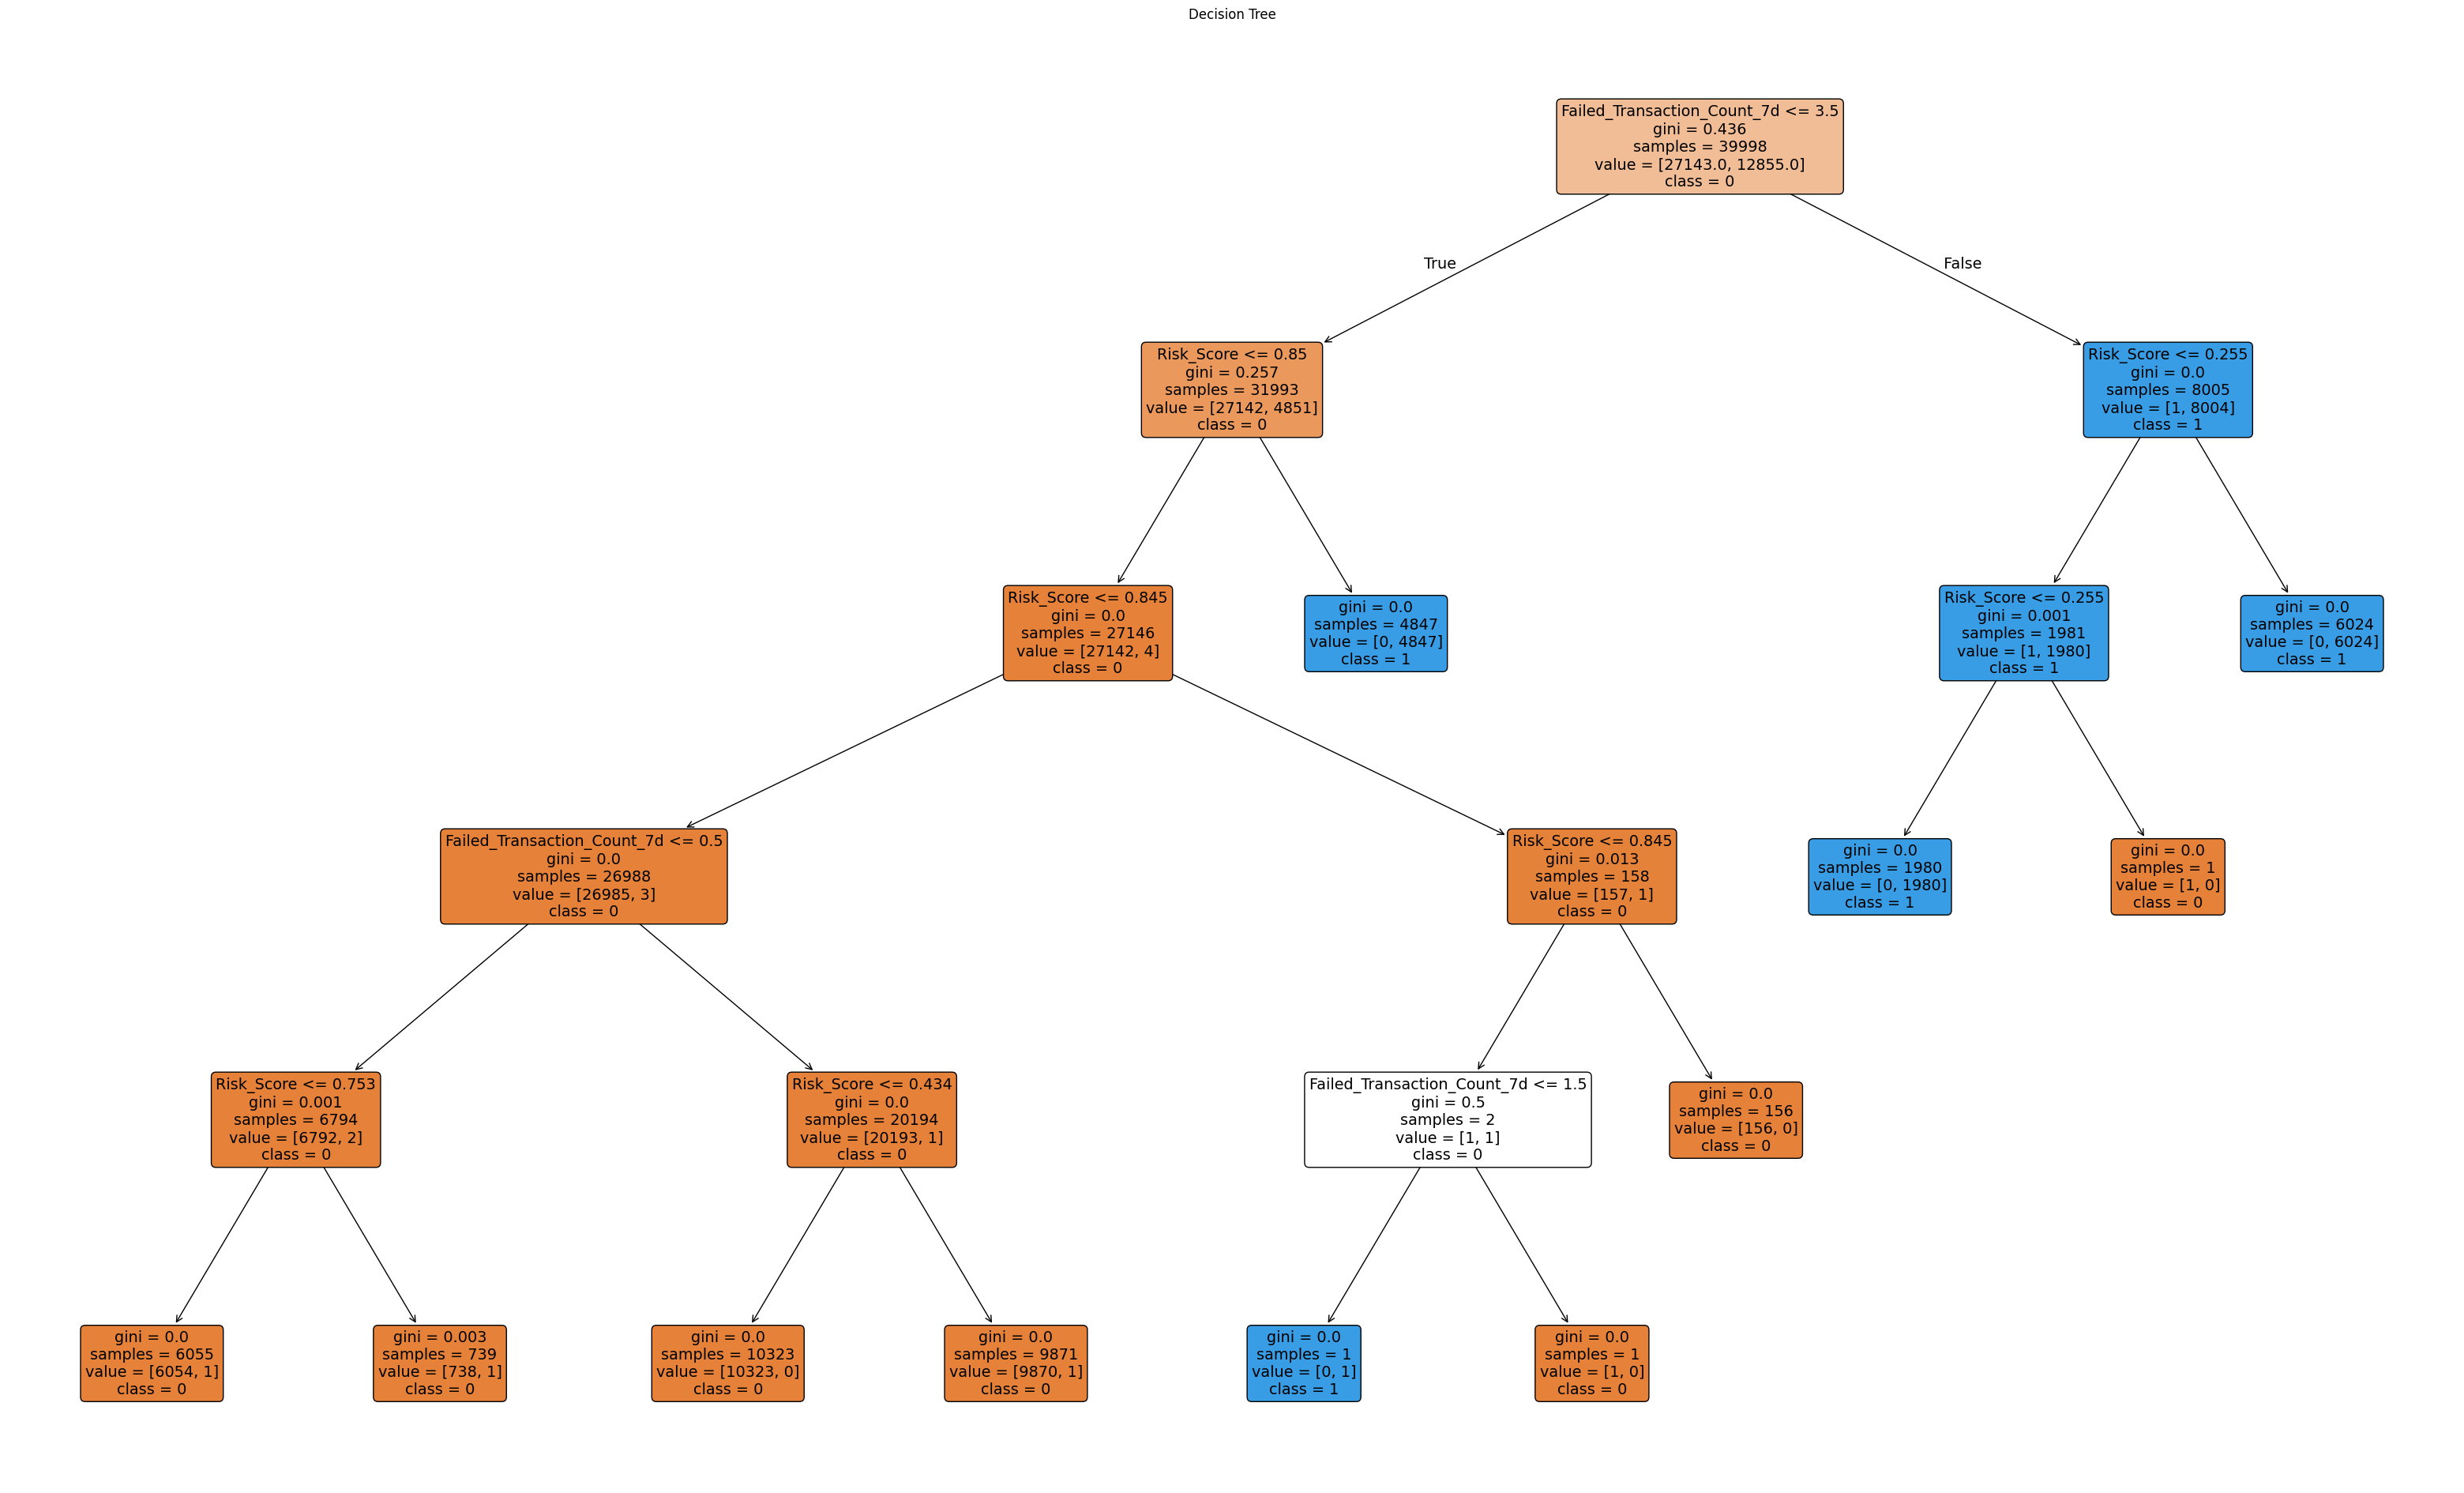

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40, 24))
plot_tree(
    dt,
    feature_names=X_train_final.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree")
plt.show()

In [5]:
from sklearn.tree import export_text

tree_rules = export_text(dt, feature_names=list(X_train_final.columns))
print(tree_rules)

|--- Failed_Transaction_Count_7d <= 3.50
|   |--- Risk_Score <= 0.85
|   |   |--- Risk_Score <= 0.85
|   |   |   |--- Failed_Transaction_Count_7d <= 0.50
|   |   |   |   |--- Risk_Score <= 0.75
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Risk_Score >  0.75
|   |   |   |   |   |--- class: 0
|   |   |   |--- Failed_Transaction_Count_7d >  0.50
|   |   |   |   |--- Risk_Score <= 0.43
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Risk_Score >  0.43
|   |   |   |   |   |--- class: 0
|   |   |--- Risk_Score >  0.85
|   |   |   |--- Risk_Score <= 0.85
|   |   |   |   |--- Failed_Transaction_Count_7d <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Failed_Transaction_Count_7d >  1.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Risk_Score >  0.85
|   |   |   |   |--- class: 0
|   |--- Risk_Score >  0.85
|   |   |--- class: 1
|--- Failed_Transaction_Count_7d >  3.50
|   |--- Risk_Score <= 0.25
|   |   |--- Risk_Score <= 0.25
|   |   |   |--- class: 1
|   

## 3.2 Permutation importance

                       Feature  Importance_Mean  Importance_STD
0  Failed_Transaction_Count_7d          0.26529        0.003777
1                   Risk_Score          0.21261        0.002202


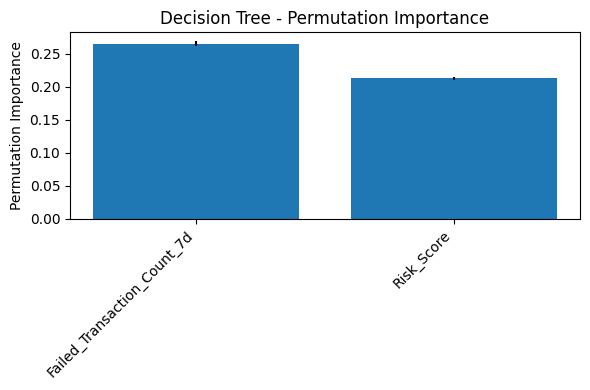

In [6]:
perm = permutation_importance(
    dt,
    X_test_final,
    y_test_final,
    n_repeats=20,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": X_test_final.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_STD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

print(perm_df)

plt.figure(figsize=(6, 4))
plt.bar(perm_df["Feature"], perm_df["Importance_Mean"], yerr=perm_df["Importance_STD"])
plt.ylabel("Permutation Importance")
plt.title("Decision Tree - Permutation Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3.3 SHAP global bar plot

shap_values.values.shape: (10000, 2, 2)


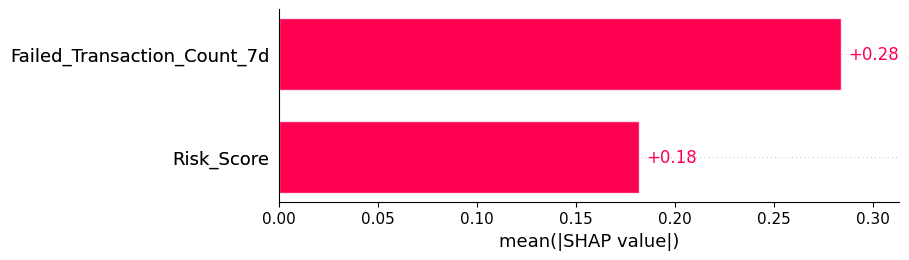

In [12]:
explainer = shap.Explainer(dt, X_train_final)
shap_values = explainer(X_test_final, check_additivity=False)

print("shap_values.values.shape:", shap_values.values.shape)

# objašnjenje za class 1 = positive class (fraud)
shap_values_class = shap_values[..., 1]

# global
shap.plots.bar(shap_values_class)



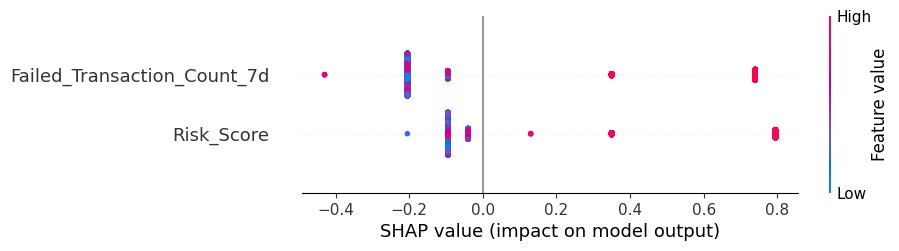

In [13]:
shap.plots.beeswarm(shap_values_class)

*Za obje značajke na lijevoj strani pojavljuju se i niske (plave) i visoke (crvene) vrijednosti. To znači da i niske i visoke vrijednosti mogu imati negativan doprinos predikciji. Razlog je skokovita, granata struktura stabla odlučivanja (DT), gdje učinak značajke ovisi o kontekstu, tj. o granama definiranim drugim značajkama. Ovakvo ponašanje može se detaljnije analizirati pomoću scatter (dependence) grafova, na kojima su jasno vidljivi pragovi (cutoff vrijednosti) na kojima dolazi do promjene doprinosa.*

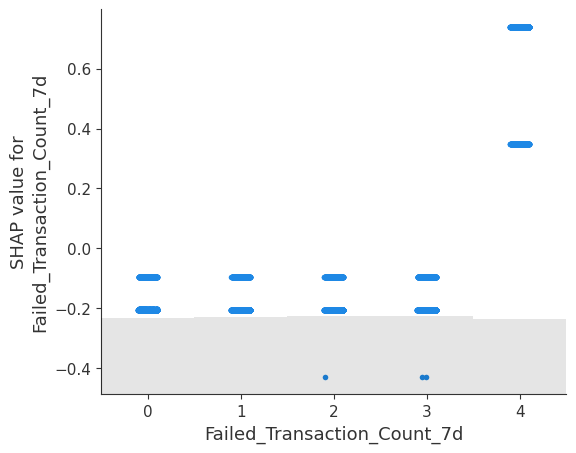

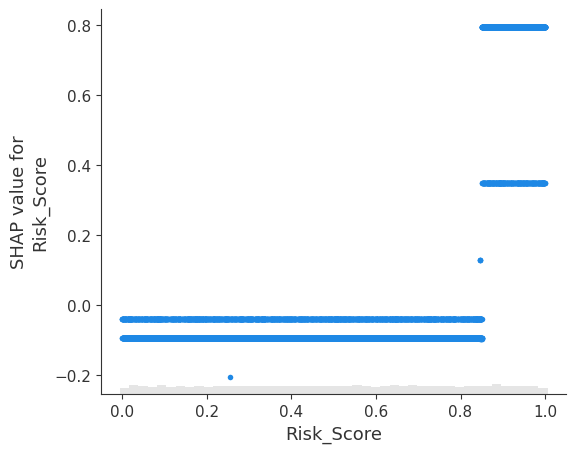

In [11]:
shap.plots.scatter(shap_values[..., 1][:, "Failed_Transaction_Count_7d"])
shap.plots.scatter(shap_values[..., 1][:, "Risk_Score"])

# 3.4 SHAP Waterfall

TP: 3213 TN: 6786 FP: 0 FN: 1

TP example
True: 1
Pred: 1
Failed_Transaction_Count_7d    2.00
Risk_Score                     0.92
Name: 41267, dtype: float64


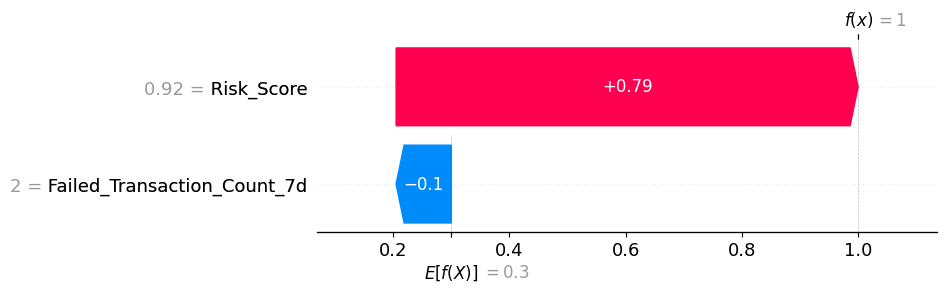


TN example
True: 0
Pred: 0
Failed_Transaction_Count_7d    1.0000
Risk_Score                     0.3111
Name: 9998, dtype: float64


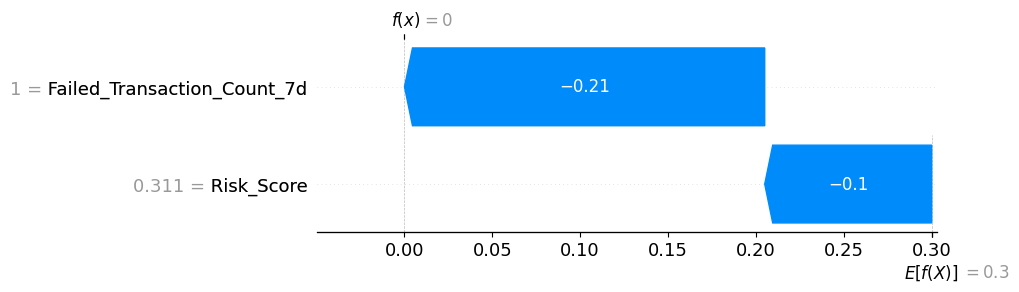


FN example
True: 1
Pred: 0
Failed_Transaction_Count_7d    0.0000
Risk_Score                     0.1777
Name: 43697, dtype: float64


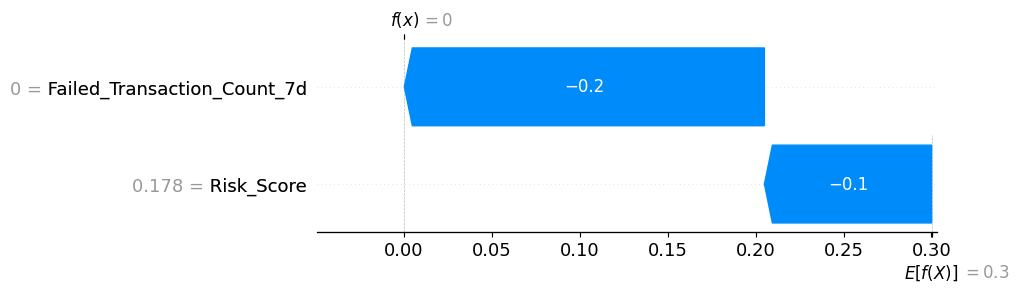

In [8]:
def plot_waterfall_from_position(pos, label_name):
    print(f"\n{label_name} example")
    print("True:", y_test_final.iloc[pos])
    print("Pred:", y_pred[pos])
    print(X_test_final.iloc[pos])

    shap.plots.waterfall(shap_values_class[pos], max_display=len(X_test_final.columns))
    plt.show()


tp_pos = np.where((y_test_final.values == 1) & (y_pred == 1))[0]
tn_pos = np.where((y_test_final.values == 0) & (y_pred == 0))[0]
fp_pos = np.where((y_test_final.values == 0) & (y_pred == 1))[0]
fn_pos = np.where((y_test_final.values == 1) & (y_pred == 0))[0]

print("TP:", len(tp_pos), "TN:", len(tn_pos), "FP:", len(fp_pos), "FN:", len(fn_pos))

if len(tp_pos) > 0:
    plot_waterfall_from_position(tp_pos[0], "TP")
if len(tn_pos) > 0:
    plot_waterfall_from_position(tn_pos[0], "TN")
if len(fp_pos) > 0:
    plot_waterfall_from_position(fp_pos[0], "FP")
if len(fn_pos) > 0:
    plot_waterfall_from_position(fn_pos[0], "FN")